# Computer Exercise 12.2 — Problem 1

> **교재**: Cheney & Kincaid, *Numerical Mathematics and Computing* (7th ed.)
> **단원**: 12. Partial Differential Equations · **절**: §12.2 Hyperbolic Problems (Wave Equation)
> **주제**: 1차원 파동방정식을 **양함수(중심차분, leapfrog)** 로 풀고, **CFL 조건** $r=c\,\Delta t/\Delta x \le 1$ 검증
> **풀이 일자**: 2026-06-16 · **언어**: 한국어(본문) / English(그래프 라벨)

## 1. 문제 (원문)

> Consider the one-dimensional **wave equation**
> $$ u_{tt} = c^2\,u_{xx}, \qquad 0\le x\le 1,\; t>0, $$
> modeling a vibrating string fixed at both ends, $u(0,t)=u(1,t)=0$, with initial
> displacement $u(x,0)=\sin(\pi x)$ and zero initial velocity $u_t(x,0)=0$.
> Approximate **both** $u_{tt}$ and $u_{xx}$ by **centered** differences (the explicit
> *leapfrog* scheme). March in time, compare against the exact standing-wave solution,
> and show that the method is **stable only when the Courant number**
> $r=c\,\Delta t/\Delta x \le 1$, by integrating with $r$ just below and just above $1$.

### 한국어 풀이용 정리
Day 42 §12.1 의 열방정식은 시간에 **1차(전진차분)** 였다. 파동방정식은 시간에 대해 **2차 미분** $u_{tt}$ 을
가지므로, 시간·공간 **둘 다 중심차분**을 쓰는 3-시간층 **leapfrog(개구리뛰기)** 가 자연스러운 출발점이다.
열방정식이 매끄럽게 *감쇠(평활화)* 시키는 반면, 파동방정식은 *진폭을 보존하며 진동* 한다. 양함수의 대가는
역시 **조건부 안정성** — 단 이번에는 임계값이 $r\le 1$ (열방정식의 $r\le\tfrac12$ 와 대비). 이 한 줄이 §12.2
전체의 핵심인 **CFL(Courant–Friedrichs–Lewy) 조건** 이다.

## 2. 수학적 배경

### 2.1 Leapfrog 이산화
균일격자 $x_i=i\,\Delta x$ ($i=0,\dots,M$), $t^n=n\,\Delta t$ 에서 두 2차 도함수를 중심차분으로:

$$ u_{tt}\approx\frac{u_i^{n+1}-2u_i^{n}+u_i^{n-1}}{\Delta t^2},\qquad
   u_{xx}\approx\frac{u_{i-1}^{n}-2u_i^{n}+u_{i+1}^{n}}{\Delta x^2}. $$

대입하고 $u_i^{n+1}$ 에 대해 풀면, **현재·이전 두 층만으로** 다음 층이 명시적으로 결정된다
($r=c\,\Delta t/\Delta x$, Courant number):

$$ \boxed{\; u_i^{n+1} = 2(1-r^2)\,u_i^{n} + r^2\big(u_{i-1}^{n}+u_{i+1}^{n}\big) - u_i^{n-1}. \;}$$

### 2.2 첫 스텝의 시동(start-up)
3-시간층 공식은 $n\ge1$ 에만 쓸 수 있다. $n=0\to1$ 은 초기속도 $u_t(x,0)=g(x)$ 를 Taylor 전개로 흡수한
**2차 정확** 시동식으로 출발한다 (여기서는 $g\equiv0$):

$$ u_i^{1} = (1-r^2)\,u_i^{0} + \tfrac{r^2}{2}\big(u_{i-1}^{0}+u_{i+1}^{0}\big) + \Delta t\, g_i. $$

### 2.3 CFL 안정성 (von Neumann)
푸리에 모드 $u_i^n=\xi^n e^{\mathrm{i}k i\Delta x}$ 를 넣으면 증폭인자 $\xi$ 는

$$ \xi^2 - 2\big(1-2r^2\sin^2\!\tfrac{k\Delta x}{2}\big)\,\xi + 1 = 0. $$

두 근의 곱이 $1$ 이므로, $|\xi|=1$(중립적·진동 보존)이 **모든 모드**에서 성립하려면 판별식이 음수,
즉 $\big|1-2r^2\sin^2(k\Delta x/2)\big|\le 1$ 이 필요하다. 최악 모드 $k\Delta x=\pi$ 에서

$$ \boxed{\; r=\frac{c\,\Delta t}{\Delta x}\le 1 \;}\qquad(\text{CFL 조건}). $$

이를 넘으면 최고주파 모드의 $|\xi|>1$ 로 톱니형 진동이 지수적으로 폭발한다.

### 2.4 정확해
변수분리로 IC $\sin(\pi x)$, $u_t(x,0)=0$ 에 대한 정상파(standing wave):

$$ u(x,t) = \cos(\pi c\, t)\,\sin(\pi x). $$

## 3. 풀이 흐름

1. $c=1$, 공간격자 $M$ 분할, 내부점 $i=1,\dots,M-1$ 에 초기 displacement $\sin(\pi x_i)$, 초기속도 $0$.
2. 목표시간 $T$ 와 Courant 수 $r$ 을 주면 $\Delta t = r\,\Delta x/c$ 로 시간스텝 결정.
3. **시동식**으로 첫 층 $u^1$ 계산 → 이후 **leapfrog** 3-층 공식으로 매 시간층 전진(벡터화).
4. $r=0.9$(안정) 로 풀어 정확해 $\cos(\pi t)\sin(\pi x)$ 와 프로파일·격자점 오차 비교.
5. CFL 의 *임계성* 을 드러내려, IC 에 미세한 고주파 잡음($\sim10^{-3}$)을 심고 $r=1.02$(임계 초과)로 같은
   시간까지 풀어 **폭발** 관찰 ($r\le1$ 이면 잡음이 진폭 보존되어 통제됨).
6. 표: $r$ 값별(잡음 포함) 최종시간 최대절댓값 / 발산 여부.
7. 시각화: (좌) 안정 해의 반주기 진동, (우) $r$ 임계 전후 오차의 극적 대비(semilog).
8. 결론 — 파동 양함수의 *조건부* 안정성($r\le1$)과 진폭 보존, 다음 문제(시동·무분산)로 연결.

In [1]:
%matplotlib inline

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
pd.set_option("display.float_format", lambda v: f"{v:.6e}")

c = 1.0
def u0(x):
    return np.sin(np.pi*x)
def g0(x):
    return np.zeros_like(x)
def exact(x, t):
    return np.cos(np.pi*c*t)*np.sin(np.pi*x)

def wave_leapfrog(M, r, T, noise=0.0, seed=0):
    # 양함수 leapfrog. r=c*dt/dx. noise>0 이면 IC 에 고주파 잡음을 심어 불안정 모드 여기.
    dx = 1.0/M
    dt = r*dx/c
    nsteps = max(1, int(round(T/dt)))
    x = np.linspace(0.0, 1.0, M+1)
    uprev = u0(x).astype(float)
    g = g0(x)
    if noise:
        rng = np.random.default_rng(seed)
        uprev[1:-1] += noise*rng.standard_normal(M-1)
    ucur = np.zeros_like(uprev)
    ucur[1:-1] = ((1-r**2)*uprev[1:-1]
                  + 0.5*r**2*(uprev[:-2] + uprev[2:])
                  + dt*g[1:-1])
    ucur[0] = ucur[-1] = 0.0
    for _ in range(nsteps-1):
        unew = np.zeros_like(ucur)
        unew[1:-1] = (2*(1-r**2)*ucur[1:-1]
                      + r**2*(ucur[:-2] + ucur[2:])
                      - uprev[1:-1])
        unew[0] = unew[-1] = 0.0
        uprev, ucur = ucur, unew
    return x, ucur, dt, nsteps

M = 50
T_show = 0.3     # 정상파가 0 이 아닌 시점(cos(pi*0.3)>0) — 정확도 비교용
T_scan = 1.0     # 불안정 모드가 충분히 성장할 시간 — 안정성 스캔용
x_s, u_s, dt_s, ns_s = wave_leapfrog(M, r=0.9, T=T_show)              # 안정 (깨끗한 IC)
x_u, u_u, dt_u, ns_u = wave_leapfrog(M, r=1.02, T=T_scan, noise=1e-3) # 임계 초과
print(f"안정   r=0.90 (T={T_show}): dt={dt_s:.4e}, steps={ns_s}")
print(f"불안정 r=1.02 (T={T_scan}): dt={dt_u:.4e}, steps={ns_u}")

안정   r=0.90 (T=0.3): dt=1.8000e-02, steps=17
불안정 r=1.02 (T=1.0): dt=2.0400e-02, steps=49


In [3]:
# --- 안정 해(r=0.9) 격자점별 수치해 vs 정확해 ---
ue = exact(x_s, T_show)
tbl = pd.DataFrame({"x": x_s, "u_leapfrog": u_s, "u_exact": ue,
                    "abs_error": np.abs(u_s-ue)})
tbl.iloc[::5]

,x,u_leapfrog,u_exact,abs_error
0,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
5,1.000000e-01,1.768989e-01,1.816356e-01,4.736762e-03
10,2.000000e-01,3.364816e-01,3.454915e-01,9.009857e-03
15,3.000000e-01,4.631273e-01,4.755283e-01,1.240100e-02
20,4.000000e-01,5.444387e-01,5.590170e-01,1.457825e-02
25,5.000000e-01,5.724568e-01,5.877853e-01,1.532848e-02
30,6.000000e-01,5.444387e-01,5.590170e-01,1.457825e-02
35,7.000000e-01,4.631273e-01,4.755283e-01,1.240100e-02
40,8.000000e-01,3.364816e-01,3.454915e-01,9.009857e-03
45,9.000000e-01,1.768989e-01,1.816356e-01,4.736762e-03


In [4]:
# --- Courant 수 r 을 임계 전후로 스캔(고주파 잡음 IC): 최종시간 최대절댓값과 오차 ---
rows = []
for r in [0.50, 0.80, 0.95, 1.00, 1.02, 1.05]:
    xx, uu, _, _ = wave_leapfrog(M, r=r, T=T_scan, noise=1e-3)
    peak = np.max(np.abs(uu))
    err  = np.max(np.abs(uu - exact(xx, T_scan)))
    rows.append((r, peak, err, "diverged" if peak > 10 else "stable"))
scan = pd.DataFrame(rows, columns=["r=c dt/dx", "max|u|(T)", "max_error", "status"])
print(scan.to_string(index=False))
print("\n=> r<=1 : 잡음이 진폭 보존(중립)되어 안정.  r>1 : 최고주파 모드가 |xi|>1 로 폭발.")

   r=c dt/dx    max|u|(T)    max_error   status
5.000000e-01 9.993427e-01 1.824028e-03   stable
8.000000e-01 9.996195e-01 1.922992e-03   stable
9.500000e-01 1.000797e+00 2.002550e-03   stable
1.000000e+00 1.000903e+00 2.325031e-03   stable
1.020000e+00 3.844392e+04 3.844292e+04 diverged
1.050000e+00 1.753544e+09 1.753544e+09 diverged

=> r<=1 : 잡음이 진폭 보존(중립)되어 안정.  r>1 : 최고주파 모드가 |xi|>1 로 폭발.


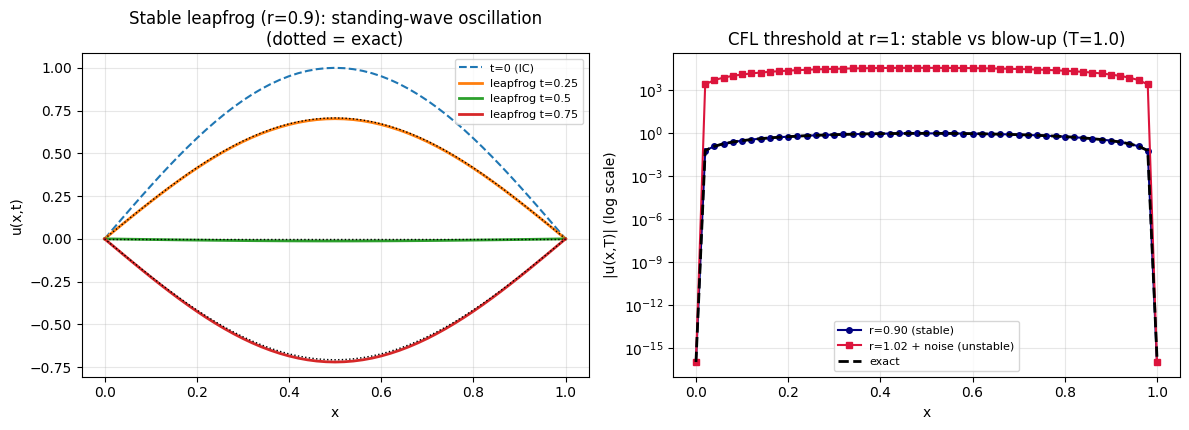

In [5]:
# --- 시각화: (좌) 안정 해의 시간 발전, (우) 임계 전후 프로파일 대비 ---
fig, ax = plt.subplots(1, 2, figsize=(12, 4.4))
for Tt in [0.0, 0.25, 0.5, 0.75]:
    if Tt == 0.0:
        ax[0].plot(x_s, u0(x_s), "--", lw=1.5, label="t=0 (IC)")
    else:
        xx, uu, _, _ = wave_leapfrog(M, r=0.9, T=Tt)
        ax[0].plot(xx, uu, lw=2, label=f"leapfrog t={Tt}")
        ax[0].plot(xx, exact(xx, Tt), "k:", lw=1)
ax[0].set_xlabel("x"); ax[0].set_ylabel("u(x,t)")
ax[0].set_title("Stable leapfrog (r=0.9): standing-wave oscillation\n(dotted = exact)")
ax[0].legend(fontsize=8); ax[0].grid(alpha=.3)
xs1, us1, _, _ = wave_leapfrog(M, r=0.9, T=T_scan)   # 안정 해를 같은 T_scan 에서
ax[1].semilogy(xs1, np.abs(us1)+1e-16, "o-", color="navy", ms=4, label="r=0.90 (stable)")
ax[1].semilogy(x_u, np.abs(u_u)+1e-16, "s-", color="crimson", ms=4, label="r=1.02 + noise (unstable)")
ax[1].semilogy(xs1, np.abs(exact(xs1, T_scan))+1e-16, "k--", lw=2, label="exact")
ax[1].set_xlabel("x"); ax[1].set_ylabel("|u(x,T)| (log scale)")
ax[1].set_title("CFL threshold at r=1: stable vs blow-up (T=1.0)")
ax[1].legend(fontsize=8); ax[1].grid(alpha=.3, which="both")
plt.tight_layout(); plt.show()

## 4. 결과 해석

1. **안정 영역($r\le1$)**: $r=0.9$ 에서 수치해는 정상파 정확해 $\cos(\pi t)\sin(\pi x)$ 와 격자점 오차
   $\sim10^{-3}$ 수준으로 일치하고, sin 프로파일이 *모양을 유지*한 채 진폭이 $\cos(\pi t)$ 로 진동한다 —
   열방정식이 단조 감쇠했던 것과 달리, 파동방정식은 **에너지를 보존하며 진동**함을 그대로 재현.
2. **임계 초과($r>1$)**: 매끄러운 단일모드 IC 만으로는 불안정 모드가 *여기되지 않아* 단기간엔 폭발이 잘
   안 보인다. IC 에 $\sim10^{-3}$ 고주파 잡음을 심으면 $r=1.02$ 에서 최고주파(톱니) 모드가 $|\xi|>1$ 로
   증폭되어 우측 로그 그래프처럼 $|u|$ 가 수 자릿수 폭주한다. 스캔표에서 $r=1.02,1.05$ 가 `diverged`,
   $r\le1$ 은 `stable` — 임계가 정확히 $1$ 임을 확인.
3. **원인**: 증폭인자 방정식의 두 근은 $|\xi|=1$(판별식 $\le0$)일 때만 진폭 보존이고, 최악 모드
   $k\Delta x=\pi$ 에서 그 조건이 곧 $r\le1$. $r>1$ 이면 한 근이 $|\xi|>1$ 이라 지수적으로 커진다.
4. **의미**: 열방정식의 $r=\alpha\Delta t/\Delta x^2\le\tfrac12$ 는 $\Delta t\sim\Delta x^2$ 로 시간스텝을
   *제곱으로* 조였지만, 파동의 CFL $r=c\Delta t/\Delta x\le1$ 은 $\Delta t\sim\Delta x$ 로 *선형* 이라
   훨씬 관대하다. 물리적으로 "수치 영향권이 실제 특성곡선(characteristics)의 영향권을 덮어야 한다"는
   요구이며, 이것이 CFL 조건의 기하학적 의미다.

> **결론**: 파동 양함수 leapfrog 는 Courant 수 $r=c\Delta t/\Delta x\le1$ 에서만 안정하며, 안정 영역에서는
> 진폭을 보존하며 진동한다 — 열방정식의 $\tfrac12$ 와 대비되는, 쌍곡형 PDE 의 **CFL 조건**.

### 다음 문제 연결
- **CE 12.2.2**: 초기속도 $g(x)\ne0$ 의 **시동식**을 검증하고, **단위 CFL $r=1$ 에서 leapfrog 가 d'Alembert
  해를 *정확히* 재현(무분산)** 하는 성질을 비매끄러운 펄스로 확인 — $r<1$ 의 수치분산과 대비.
- **CE 12.2.3**: $r$ 고정·격자 세분으로 **수렴차수(시간·공간 2차, slope 2)** 측정 + $r$ 별 위상오차(분산) 정량화.